https://velog.io/@jochedda/%ED%81%B4%EB%9F%AC%EC%8A%A4%ED%84%B0%EB%A7%81-%ED%8F%89%EA%B0%80%EC%A7%80%ED%91%9C-%EC%8B%A4%EB%A3%A8%EC%97%A3-%EA%B3%84%EC%88%98Silhouette-Coefficient


https://studying-haeung.tistory.com/10

![alt text](image-1.png)

In [1]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

iris = load_iris()
feature_names = ['sepal_length','sepal_width','petal_length','petal_width']

df_iris = pd.DataFrame(data = iris.data,columns = feature_names)
kmeans = KMeans(n_clusters = 3,random_state=42).fit(df_iris)
df_iris['cluster'] = kmeans.labels_

average_coef = silhouette_score(iris.data , df_iris['cluster'])
print(f'평균 실루엣 값:{average_coef:.4f}')

#평균 실루엣 값 (silhouette score) = 0.5512라면, 결론부터 말하면 “군집이 꽤 잘 나뉜 편이다 (중간 이상, 양호)”라고 해석하면 됩니다.

# 🔎 실루엣 계수 기준 먼저 이해

# 실루엣 값은 -1 ~ 1 사이 값을 가집니다.

# 1에 가까울수록 👉 군집이 매우 잘 분리됨
# 0 근처 👉 군집이 서로 겹침
# 음수 👉 잘못 군집됨 (다른 군집이 더 가까움)


# 🌸 Iris 데이터 기준으로 보면

# Iris dataset 은 원래 3개의 클래스가 있음:

# Setosa 👉 매우 잘 분리됨
# Versicolor / Virginica 👉 서로 약간 겹침

# 그래서 보통:

# 0.5 ~ 0.6 정도가 나오면 정상
# 0.55면 👉 딱 평균 이상 잘 된 결과

df_iris.head(10)

평균 실루엣 값:0.5512


,sepal_length,sepal_width,petal_length,petal_width,cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
5,5.4,3.9,1.7,0.4,1
6,4.6,3.4,1.4,0.3,1
7,5.0,3.4,1.5,0.2,1
8,4.4,2.9,1.4,0.2,1
9,4.9,3.1,1.5,0.1,1


🔥 자동 선택된 최적 K: 3


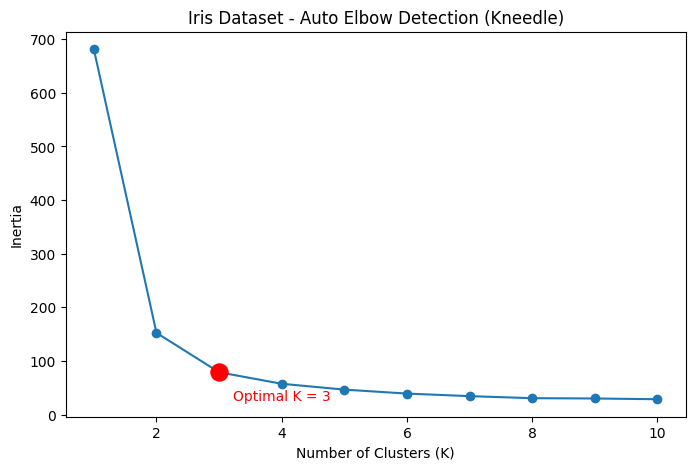

In [4]:
%pip install kneed
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from kneed import KneeLocator

# 1️⃣ 데이터 로드
iris = load_iris()
X = iris.data

# 2️⃣ K 범위 설정
k_range = range(1, 11)

# 3️⃣ inertia 계산
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# 4️⃣ KneeLocator로 elbow 찾기
knee = KneeLocator(
    k_range,
    inertias,
    curve="convex",
    direction="decreasing"
)

optimal_k = knee.knee
optimal_inertia = inertias[optimal_k - 1]

print("🔥 자동 선택된 최적 K:", optimal_k)

# 5️⃣ 시각화
plt.figure(figsize=(8,5))
plt.plot(k_range, inertias, marker='o')

# 🔴 최적 K 강조
plt.scatter(optimal_k, optimal_inertia, color='red', s=150, zorder=5)

plt.annotate(
    f"Optimal K = {optimal_k}",
    (optimal_k, optimal_inertia),
    textcoords="offset points",
    xytext=(10, -20),
    color='red'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Iris Dataset - Auto Elbow Detection (Kneedle)")
plt.show()

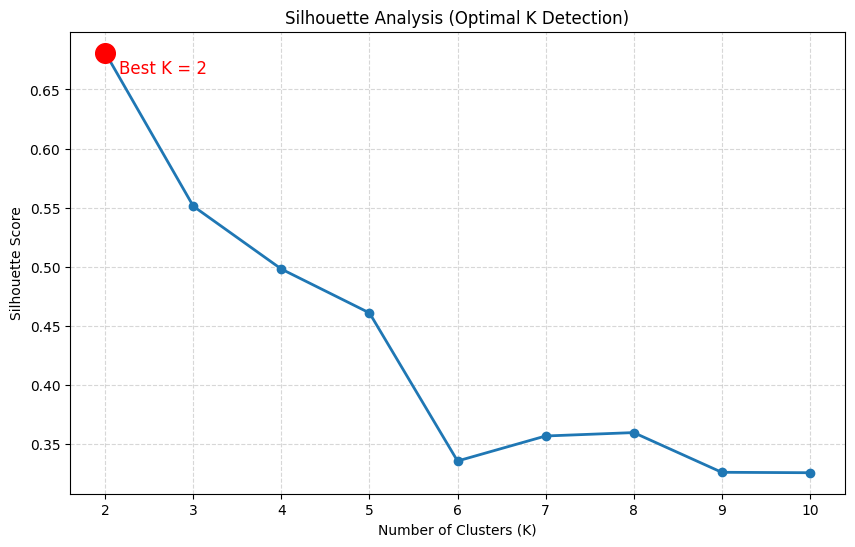

🔥 최적 K (Silhouette 기준): 2
🔥 최고 Silhouette Score: 0.681


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# K 범위
k_range = range(2, 11)

sil_scores = []

# 1️⃣ Silhouette 계산
for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=0
    )

    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)


# 2️⃣ 최적 K 찾기 (실루엣 최대값)
best_k = k_range[sil_scores.index(max(sil_scores))]
best_score = max(sil_scores)


# 3️⃣ 시각화
plt.figure(figsize=(10,6))

plt.plot(
    k_range,
    sil_scores,
    marker="o",
    linewidth=2
)

# 🔴 최고점 강조
plt.scatter(
    best_k,
    best_score,
    color="red",
    s=200,
    zorder=5
)

# 🔴 텍스트 표시
plt.annotate(
    f"Best K = {best_k}",
    (best_k, best_score),
    textcoords="offset points",
    xytext=(10, -15),
    color="red",
    fontsize=12
)

# 스타일
plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(list(k_range))
plt.xlabel("Number of Clusters (K)")

plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis (Optimal K Detection)")
plt.show()


# 4️⃣ 결과 출력
print("🔥 최적 K (Silhouette 기준):", best_k)
print("🔥 최고 Silhouette Score:", round(best_score, 4))